# Spark MLlib Taxi Demand Demo

This notebook is a simple monthly taxi-demand modeling demo for the NYC taxi architecture. It reads the existing Iceberg ML table or portable Parquet export, combines Yellow Taxi and HVFHV into one demand target, trains a few readable Spark models, and saves precomputed predictions for the Streamlit layer.

**Goal:** predict `trip_count` for a pickup zone and time. The model intentionally ignores `source_id` and `source_name` so both taxi sources are treated as one combined demand signal.

## Demo Outline

1. Start Spark.
2. Load the existing ML dataset.
3. Combine source rows and create reproducible historical features.
4. Split 2023-2024 training data from the 2025 holdout set.
5. Train four simple fixed-parameter models once.
6. Compare RMSE, MAE, and R2 across the fixed models.
7. Save the best trained model and evaluate diagnostics on the 2025 holdout set.
8. Compare actual versus predicted trip counts on the 2025 holdout set.
9. Rank pickup-location accuracy for the final 2025 predictions.
10. Save the best trained model.
11. Save a Streamlit-ready prediction table for a selected month.

The notebook uses the full dataset by default. Set `DEMO_MODE = True` only for a quick local smoke test; that optional mode keeps fewer dates through `DEMO_DATE_STRIDE_DAYS`.


## 1. Start Spark

The project source of truth is the Iceberg table. This cell loads the Iceberg Spark runtime package before Spark starts.

If you are running the notebook from VS Code on your Mac, Docker must expose both HDFS ports:

- NameNode RPC: `localhost:9000`
- DataNode transfer: `localhost:9866`

If Spark was already started with different settings, restart the notebook kernel before running this cell again.

In [1]:
from pathlib import Path
import gc
import zipfile

from pyspark import SparkContext
from pyspark.ml import Pipeline
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.regression import GBTRegressor, LinearRegression, RandomForestRegressor
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from xgboost.spark import SparkXGBRegressor

RUNNING_IN_DOCKER = Path("/workspace").exists()

# Use "iceberg" for the project pipeline, or "parquet" for a teammate-friendly export.
INPUT_MODE = "parquet"
# INPUT_MODE = "iceberg"

# Full-data run by default. Set DEMO_MODE = True only for a quick local smoke test.
DEMO_MODE = True

# This is the month exported for Streamlit. Change it when you want a new monthly demo table.
SERVING_PREDICTION_YEAR = 2025
SERVING_PREDICTION_MONTH = 1

# In demo mode, keep accurate counts but use fewer dates across each year.
DEMO_DATE_STRIDE_DAYS = 14

# Include SparkXGB as the fourth fixed model when the package is available.
RUN_XGBOOST_MODEL = True

# Spark runtime controls. Keep local concurrency small; tree models cache large internal blocks during fit.
SPARK_MASTER = "local[2]"
SHUFFLE_PARTITIONS = "2" if DEMO_MODE else "12"
PLOT_SAMPLE_FRACTION = 0.02
PLOT_SAMPLE_LIMIT = 5000
CACHE_STORAGE_LEVEL = StorageLevel.DISK_ONLY

ICEBERG_PACKAGE = "org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.5.2"
ICEBERG_WAREHOUSE = (
    "hdfs://namenode:9000/user/data/warehouse"
    if RUNNING_IN_DOCKER
    else "hdfs://localhost:9000/user/data/warehouse"
)
ML_TABLE = "nyc.taxi_demand_ml"
PORTABLE_PARQUET_PATH = (
    "/workspace/output/taxi_demand_ml_parquet"
    if RUNNING_IN_DOCKER
    else "output/taxi_demand_ml_parquet"
)
PORTABLE_PARQUET_ZIP_PATH = f"{PORTABLE_PARQUET_PATH}.zip"
ZONE_LOOKUP_PATH = "/workspace/data/taxi_zone_lookup.csv" if RUNNING_IN_DOCKER else "data/taxi_zone_lookup.csv"

# If this cell is rerun after a failed Spark startup, force Spark to rebuild with the current config.
active_session = SparkSession.getActiveSession()
if active_session is not None:
    active_session.stop()
elif SparkContext._active_spark_context is not None:
    SparkContext._active_spark_context.stop()

spark_builder = (
    SparkSession.builder
    .appName("Spark MLlib Taxi Demand Demo")
    .master(SPARK_MASTER)
    .config("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS)
    .config("spark.default.parallelism", SHUFFLE_PARTITIONS)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.python.worker.reuse", "false")
    .config("spark.driver.memory", "4g")
)

if INPUT_MODE == "iceberg":
    spark_builder = (
        spark_builder
        .config("spark.jars.packages", ICEBERG_PACKAGE)
        .config("spark.sql.catalog.nyc", "org.apache.iceberg.spark.SparkCatalog")
        .config("spark.sql.catalog.nyc.type", "hadoop")
        .config("spark.sql.catalog.nyc.warehouse", ICEBERG_WAREHOUSE)
        .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
        .config("spark.hadoop.dfs.client.use.datanode.hostname", "false" if RUNNING_IN_DOCKER else "true")
    )

spark = spark_builder.getOrCreate()
spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Input mode: {INPUT_MODE}")
print(f"Demo mode: {DEMO_MODE}")
print(f"Demo date stride days: {DEMO_DATE_STRIDE_DAYS}")
print(f"Spark master: {SPARK_MASTER}")
print(f"Shuffle partitions: {SHUFFLE_PARTITIONS}")
print(f"Run Spark XGBoost model: {RUN_XGBOOST_MODEL}")
print(f"Cache storage level: {CACHE_STORAGE_LEVEL}")
print(f"Streamlit prediction month: {SERVING_PREDICTION_YEAR}-{SERVING_PREDICTION_MONTH:02d}")
if INPUT_MODE == "iceberg":
    print(f"Iceberg warehouse: {ICEBERG_WAREHOUSE}")
else:
    print("Iceberg package/config skipped for parquet input")


/usr/local/lib/python3.8/dist-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/08 05:11:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3
Input mode: parquet
Demo mode: True
Demo date stride days: 14
Spark master: local[2]
Shuffle partitions: 2
Run Spark XGBoost model: True
Cache storage level: Disk Serialized 1x Replicated
Streamlit prediction month: 2025-01
Iceberg package/config skipped for parquet input


## Optional: Create a Portable Parquet Export

Run this cell only if you have the Iceberg table and want to share the demo dataset. Send your teammate the exported folder, not random data files from the Iceberg warehouse.

A clean Parquet export has the rows and schema the ML demo needs. The Iceberg warehouse also contains table metadata and manifests, so copying only warehouse parquet files is fragile.

In [2]:
# Uncomment and run this once to create a portable dataset for teammates.
# (
#     spark.read.table(ML_TABLE)
#     .coalesce(4)
#     .write
#     .mode("overwrite")
#     .parquet(PORTABLE_PARQUET_PATH)
# )
# print(f"Wrote portable Parquet export to {PORTABLE_PARQUET_PATH}")


## 2. Load the ML Dataset

With `INPUT_MODE = "parquet"`, this reads the local portable Parquet export and does not scan the Iceberg table. The notebook still uses Spark MLlib for modeling.

The input table can still contain `source_id` and `source_name`; those columns are ignored after loading.

In [3]:
required_columns = [
    "PULocationID",
    "pickup_year",
    "pickup_month",
    "pickup_day_of_week",
    "pickup_hour",
    "is_weekend",
    "trip_count",
]

if INPUT_MODE == "iceberg":
    raw_df = spark.read.table(ML_TABLE)
    input_description = ML_TABLE
elif INPUT_MODE == "parquet":
    parquet_path = Path(PORTABLE_PARQUET_PATH)
    parquet_zip_path = Path(PORTABLE_PARQUET_ZIP_PATH)
    if not parquet_path.exists() and parquet_zip_path.exists():
        print(f"Extracting {parquet_zip_path} to {parquet_path.parent}")
        with zipfile.ZipFile(parquet_zip_path, "r") as archive:
            archive.extractall(parquet_path.parent)
    raw_df = spark.read.parquet(PORTABLE_PARQUET_PATH)
    input_description = PORTABLE_PARQUET_PATH
else:
    raise ValueError('INPUT_MODE must be "iceberg" or "parquet"')

missing_columns = [column for column in required_columns if column not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if "pickup_date" not in raw_df.columns and "pickup_day" not in raw_df.columns:
    raise ValueError("The notebook needs pickup_date or pickup_day to build monthly prediction features.")

if raw_df.limit(1).count() == 0:
    raise ValueError(f"No rows found in {input_description}")

zone_lookup_df = (
    spark.read
    .option("header", True)
    .csv(ZONE_LOOKUP_PATH)
    .select(
        F.col("LocationID").cast("long").alias("PULocationID"),
        F.col("Borough").alias("borough"),
        F.col("Zone").alias("zone"),
        F.col("service_zone").alias("service_zone"),
    )
)

print(f"Loaded dataset from {input_description}")
print(f"Input partitions: {raw_df.rdd.getNumPartitions()}")
raw_df.printSchema()
raw_df.select([column for column in required_columns if column in raw_df.columns]).show(5, truncate=False)

Loaded dataset from /workspace/output/taxi_demand_ml_parquet
Input partitions: 2
root
 |-- source_id: long (nullable = true)
 |-- source_name: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- pickup_date: date (nullable = true)
 |-- pickup_year: long (nullable = true)
 |-- pickup_month: long (nullable = true)
 |-- pickup_day: long (nullable = true)
 |-- pickup_hour: long (nullable = true)
 |-- pickup_day_of_week: long (nullable = true)
 |-- is_weekend: boolean (nullable = true)
 |-- trip_count: long (nullable = true)

+------------+-----------+------------+------------------+-----------+----------+----------+
|PULocationID|pickup_year|pickup_month|pickup_day_of_week|pickup_hour|is_weekend|trip_count|
+------------+-----------+------------+------------------+-----------+----------+----------+
|249         |2023       |4           |1                 |23         |true      |57        |
|238         |2023       |5           |2                 |2          |false     |

## 3. Prepare Monthly Modeling Columns

The existing ML table is source-split, so the first step is to combine Yellow Taxi and HVFHV into one demand target.

The important fix here is the complete location/date/hour grid. If a pickup location has no trips for a date and hour, the notebook now creates that row with `trip_count = 0`. Without those rows, the model mostly learns from hours where trips happened and can overpredict quiet locations.

In [4]:
def date_from_year_month_day(year_col, month_col, day_col):
    return F.to_date(
        F.concat_ws(
            "-",
            year_col.cast("string"),
            F.format_string("%02d", month_col),
            F.format_string("%02d", day_col),
        )
    )


def build_source_agnostic_demand(input_df):
    select_columns = [
        F.col("PULocationID").cast("long").alias("PULocationID"),
        F.col("pickup_year").cast("int").alias("pickup_year"),
        F.col("pickup_month").cast("int").alias("pickup_month"),
        F.col("pickup_day_of_week").cast("int").alias("pickup_day_of_week"),
        F.col("pickup_hour").cast("int").alias("pickup_hour"),
        F.col("is_weekend").cast("boolean").alias("is_weekend"),
        F.col("trip_count").cast("double").alias("trip_count"),
    ]

    if "pickup_date" in input_df.columns:
        select_columns.append(F.to_date("pickup_date").alias("pickup_date"))
    if "pickup_day" in input_df.columns:
        select_columns.append(F.col("pickup_day").cast("int").alias("pickup_day"))

    base_df = input_df.select(*select_columns)

    if "pickup_day" not in base_df.columns:
        base_df = base_df.withColumn("pickup_day", F.dayofmonth("pickup_date"))
    if "pickup_date" not in base_df.columns:
        base_df = base_df.withColumn(
            "pickup_date",
            date_from_year_month_day(F.col("pickup_year"), F.col("pickup_month"), F.col("pickup_day")),
        )

    return (
        base_df
        .dropna(subset=[
            "PULocationID",
            "pickup_date",
            "pickup_year",
            "pickup_month",
            "pickup_day",
            "pickup_day_of_week",
            "pickup_hour",
            "is_weekend",
            "trip_count",
        ])
        .groupBy(
            "PULocationID",
            "pickup_date",
            "pickup_year",
            "pickup_month",
            "pickup_day",
            "pickup_day_of_week",
            "pickup_hour",
            "is_weekend",
        )
        .agg(F.sum("trip_count").alias("trip_count"))
        .withColumn("month_index", F.col("pickup_year") * F.lit(12) + F.col("pickup_month"))
        .withColumn("PULocationID_string", F.col("PULocationID").cast("string"))
        .withColumn("is_weekend_int", F.col("is_weekend").cast("int"))
    )


def select_modeling_dates(demand_df):
    date_df = demand_df.select(
        "pickup_date",
        "pickup_year",
        "pickup_month",
        "pickup_day",
        "pickup_day_of_week",
        "is_weekend",
        "is_weekend_int",
        "month_index",
    ).distinct()

    if DEMO_MODE:
        date_df = date_df.filter(F.pmod(F.dayofyear("pickup_date"), F.lit(DEMO_DATE_STRIDE_DAYS)) == F.lit(1))

    return date_df


def build_complete_location_hour_demand(positive_demand_df):
    locations_df = positive_demand_df.select("PULocationID", "PULocationID_string").distinct()
    dates_df = select_modeling_dates(positive_demand_df)
    hours_df = spark.range(0, 24).select(F.col("id").cast("int").alias("pickup_hour"))

    grid_df = locations_df.crossJoin(dates_df).crossJoin(hours_df)
    demand_values_df = positive_demand_df.select("PULocationID", "pickup_date", "pickup_hour", "trip_count")

    return (
        grid_df
        .join(demand_values_df, ["PULocationID", "pickup_date", "pickup_hour"], "left")
        .withColumn("trip_count", F.coalesce(F.col("trip_count"), F.lit(0.0)))
        .repartition(int(SHUFFLE_PARTITIONS), "pickup_year", "pickup_month")
    )


def build_history_tables(demand_df):
    location_month = (
        demand_df
        .groupBy("PULocationID", "month_index")
        .agg(F.avg("trip_count").alias("month_location_avg"))
    )
    location_window = (
        Window
        .partitionBy("PULocationID")
        .orderBy("month_index")
        .rowsBetween(Window.unboundedPreceding, -1)
    )
    location_history = (
        location_month
        .withColumn("location_avg", F.avg("month_location_avg").over(location_window))
        .select("PULocationID", "month_index", "location_avg")
    )

    location_hour_month = (
        demand_df
        .groupBy("PULocationID", "pickup_hour", "month_index")
        .agg(
            F.avg("trip_count").alias("month_location_hour_avg"),
            F.avg(F.when(F.col("trip_count") == 0, 1.0).otherwise(0.0)).alias("month_location_hour_zero_rate"),
        )
    )
    location_hour_window = (
        Window
        .partitionBy("PULocationID", "pickup_hour")
        .orderBy("month_index")
        .rowsBetween(Window.unboundedPreceding, -1)
    )
    location_hour_history = (
        location_hour_month
        .withColumn("location_hour_avg", F.avg("month_location_hour_avg").over(location_hour_window))
        .withColumn("location_hour_zero_rate", F.avg("month_location_hour_zero_rate").over(location_hour_window))
        .select("PULocationID", "pickup_hour", "month_index", "location_hour_avg", "location_hour_zero_rate")
    )

    location_dow_hour_month = (
        demand_df
        .groupBy("PULocationID", "pickup_day_of_week", "pickup_hour", "month_index")
        .agg(F.avg("trip_count").alias("month_location_dow_hour_avg"))
    )
    location_dow_hour_window = (
        Window
        .partitionBy("PULocationID", "pickup_day_of_week", "pickup_hour")
        .orderBy("month_index")
        .rowsBetween(Window.unboundedPreceding, -1)
    )
    location_dow_hour_history = (
        location_dow_hour_month
        .withColumn("location_dow_hour_avg", F.avg("month_location_dow_hour_avg").over(location_dow_hour_window))
        .select("PULocationID", "pickup_day_of_week", "pickup_hour", "month_index", "location_dow_hour_avg")
    )

    previous_month_location_hour = (
        location_hour_month
        .select(
            "PULocationID",
            "pickup_hour",
            (F.col("month_index") + F.lit(1)).alias("month_index"),
            F.col("month_location_hour_avg").alias("previous_month_location_hour_avg"),
        )
    )

    hour_month = (
        demand_df
        .groupBy("pickup_hour", "month_index")
        .agg(F.avg("trip_count").alias("month_hour_avg"))
    )
    hour_window = (
        Window
        .partitionBy("pickup_hour")
        .orderBy("month_index")
        .rowsBetween(Window.unboundedPreceding, -1)
    )
    hour_history = (
        hour_month
        .withColumn("hour_avg", F.avg("month_hour_avg").over(hour_window))
        .select("pickup_hour", "month_index", "hour_avg")
    )

    return {
        "location_history": location_history,
        "location_hour_history": location_hour_history,
        "location_dow_hour_history": location_dow_hour_history,
        "previous_month_location_hour": previous_month_location_hour,
        "hour_history": hour_history,
    }


def add_historical_features(input_df, history_tables):
    with_history = (
        input_df
        .join(history_tables["location_history"], ["PULocationID", "month_index"], "left")
        .join(history_tables["location_hour_history"], ["PULocationID", "pickup_hour", "month_index"], "left")
        .join(history_tables["location_dow_hour_history"], ["PULocationID", "pickup_day_of_week", "pickup_hour", "month_index"], "left")
        .join(history_tables["previous_month_location_hour"], ["PULocationID", "pickup_hour", "month_index"], "left")
        .join(history_tables["hour_history"], ["pickup_hour", "month_index"], "left")
        .withColumn("location_avg", F.coalesce("location_avg", "hour_avg", F.lit(0.0)))
        .withColumn("location_hour_avg", F.coalesce("location_hour_avg", "location_avg", "hour_avg", F.lit(0.0)))
        .withColumn("location_dow_hour_avg", F.coalesce("location_dow_hour_avg", "location_hour_avg", "location_avg", "hour_avg", F.lit(0.0)))
        .withColumn(
            "previous_month_location_hour_avg",
            F.coalesce("previous_month_location_hour_avg", "location_hour_avg", "location_avg", "hour_avg", F.lit(0.0)),
        )
        .withColumn("location_hour_zero_rate", F.coalesce("location_hour_zero_rate", F.lit(1.0)))
        .drop("hour_avg")
    )
    return with_history


numeric_feature_cols = [
    "pickup_month",
    "pickup_day_of_week",
    "pickup_hour",
    "is_weekend_int",
    "location_avg",
    "location_hour_avg",
    "location_dow_hour_avg",
    "previous_month_location_hour_avg",
    "location_hour_zero_rate",
]
encoded_feature_cols = ["PULocationID_ohe"]

preprocessing_pipeline = Pipeline(stages=[
    StringIndexer(
        inputCol="PULocationID_string",
        outputCol="PULocationID_index",
        handleInvalid="keep",
    ),
    OneHotEncoder(
        inputCols=["PULocationID_index"],
        outputCols=["PULocationID_ohe"],
        handleInvalid="keep",
    ),
    VectorAssembler(
        inputCols=numeric_feature_cols + encoded_feature_cols,
        outputCol="features",
        handleInvalid="skip",
    ),
])

positive_demand_df = build_source_agnostic_demand(raw_df).persist(CACHE_STORAGE_LEVEL)

demand_df = build_complete_location_hour_demand(positive_demand_df).persist(CACHE_STORAGE_LEVEL)
history_tables = build_history_tables(demand_df)

dataset = (
    add_historical_features(demand_df, history_tables)
    .withColumn("label", F.col("trip_count"))
    .persist(CACHE_STORAGE_LEVEL)
)

print("Source columns ignored for ML: source_id, source_name")
print("Zero-demand location/date/hour rows are included in the model target.")
print("Numeric feature columns:")
for column in numeric_feature_cols:
    print(f"- {column}")

print("Encoded feature columns:")
for column in encoded_feature_cols:
    print(f"- {column}")

print("Monthly modeling dataset is defined. The next split cell materializes the rows.")

Source columns ignored for ML: source_id, source_name
Zero-demand location/date/hour rows are included in the model target.
Numeric feature columns:
- pickup_month
- pickup_day_of_week
- pickup_hour
- is_weekend_int
- location_avg
- location_hour_avg
- location_dow_hour_avg
- previous_month_location_hour_avg
- location_hour_zero_rate
Encoded feature columns:
- PULocationID_ohe
Monthly modeling dataset is defined. The next split cell materializes the rows.


## 4. Split Train and Test Data

The model is trained on 2023-2024 and evaluated on 2025. Historical-average features are calculated using earlier months only, so the same feature logic can be reused when a new monthly file arrives.

In [5]:
train_years = [2023, 2024]
test_year = 2025

full_train_df = dataset.filter(F.col("pickup_year").isin(train_years))
full_test_df = dataset.filter(F.col("pickup_year") == test_year)

train_df = full_train_df
test_df = full_test_df

train_df = train_df.persist(CACHE_STORAGE_LEVEL)
test_df = test_df.persist(CACHE_STORAGE_LEVEL)

train_count = train_df.count()
test_count = test_df.count()

if train_count == 0:
    raise ValueError(f"No training rows found for years: {train_years}")
if test_count == 0:
    raise ValueError(f"No test rows found for year: {test_year}")

print(f"Train years: {train_years}")
print(f"Test year: {test_year}")
print(f"Train rows used: {train_count:,}")
print(f"Test rows used: {test_count:,}")

feature_columns_to_keep = [
    "PULocationID",
    "PULocationID_string",
    "pickup_date",
    "pickup_year",
    "pickup_month",
    "pickup_day",
    "pickup_day_of_week",
    "pickup_hour",
    "is_weekend",
    "is_weekend_int",
    "month_index",
    "location_avg",
    "location_hour_avg",
    "location_dow_hour_avg",
    "previous_month_location_hour_avg",
    "location_hour_zero_rate",
    "trip_count",
    "label",
    "features",
]

serving_feature_columns_to_keep = [
    column for column in feature_columns_to_keep
    if column not in {"trip_count", "label"}
]

feature_model = preprocessing_pipeline.fit(train_df)
train_features_df = feature_model.transform(train_df).select(feature_columns_to_keep).persist(CACHE_STORAGE_LEVEL)
test_features_df = feature_model.transform(test_df).select(feature_columns_to_keep).persist(CACHE_STORAGE_LEVEL)

train_feature_count = train_features_df.count()
test_feature_count = test_features_df.count()
print(f"Train feature rows: {train_feature_count:,}")
print(f"Test feature rows: {test_feature_count:,}")

train_df.unpersist()
test_df.unpersist()

Train years: [2023, 2024]
Test year: 2025
Train rows used: 340,848
Test rows used: 170,424


Train feature rows: 340,848
Test feature rows: 170,424


DataFrame[pickup_hour: int, month_index: int, PULocationID: bigint, pickup_day_of_week: int, pickup_date: date, PULocationID_string: string, pickup_year: int, pickup_month: int, pickup_day: int, is_weekend: boolean, is_weekend_int: int, trip_count: double, location_avg: double, location_hour_avg: double, location_hour_zero_rate: double, location_dow_hour_avg: double, previous_month_location_hour_avg: double, label: double]

## 5. Train Fixed Models

This simplified version does not search parameter grids. It trains each model once with a small fixed parameter set, compares the 2025 holdout metrics, and keeps the best trained model for the remaining diagnostics.


In [6]:
def evaluate_predictions(predictions):
    metric_row = (
        predictions
        .select(
            F.col("label").cast("double").alias("label"),
            F.col("prediction").cast("double").alias("prediction"),
        )
        .where(F.col("label").isNotNull() & F.col("prediction").isNotNull())
        .select(
            "label",
            "prediction",
            F.pow(F.col("label") - F.col("prediction"), 2).alias("squared_error"),
            F.abs(F.col("label") - F.col("prediction")).alias("absolute_error"),
            F.pow(F.col("label"), 2).alias("label_squared"),
        )
        .agg(
            F.count("*").alias("row_count"),
            F.sum("squared_error").alias("sse"),
            F.sum("absolute_error").alias("absolute_error_sum"),
            F.sum("label").alias("label_sum"),
            F.sum("label_squared").alias("label_squared_sum"),
        )
        .first()
    )

    row_count = metric_row["row_count"] or 0
    if row_count == 0:
        raise ValueError("No rows available for model evaluation")

    sse = float(metric_row["sse"] or 0.0)
    absolute_error_sum = float(metric_row["absolute_error_sum"] or 0.0)
    label_sum = float(metric_row["label_sum"] or 0.0)
    label_squared_sum = float(metric_row["label_squared_sum"] or 0.0)

    rmse = (sse / row_count) ** 0.5
    mae = absolute_error_sum / row_count
    sst = label_squared_sum - ((label_sum * label_sum) / row_count)
    r2 = 0.0 if sst <= 0 else 1.0 - (sse / sst)

    return {"rmse": rmse, "mae": mae, "r2": r2}


model_specs = [
    (
        "LinearRegression",
        "linear_default",
        "maxIter=30, regParam=0.01, elasticNetParam=0.0",
        LinearRegression(
            featuresCol="features",
            labelCol="label",
            predictionCol="prediction",
            maxIter=30,
            regParam=0.01,
            elasticNetParam=0.0,
        ),
    ),
    (
        "RandomForestRegressor",
        "rf_small",
        "numTrees=20, maxDepth=5, minInstancesPerNode=5",
        RandomForestRegressor(
            featuresCol="features",
            labelCol="label",
            predictionCol="prediction",
            numTrees=20,
            maxDepth=5,
            minInstancesPerNode=5,
            featureSubsetStrategy="sqrt",
            maxMemoryInMB=128,
            seed=42,
        ),
    ),
    (
        "GBTRegressor",
        "gbt_small",
        "maxIter=10, maxDepth=2, minInstancesPerNode=20",
        GBTRegressor(
            featuresCol="features",
            labelCol="label",
            predictionCol="prediction",
            maxIter=10,
            maxDepth=2,
            minInstancesPerNode=20,
            subsamplingRate=0.7,
            maxMemoryInMB=128,
            seed=42,
        ),
    ),
]

if RUN_XGBOOST_MODEL:
    model_specs.append(
        (
            "SparkXGBRegressor",
            "xgb_tiny",
            "n_estimators=10, max_depth=2, learning_rate=0.08",
            SparkXGBRegressor(
                features_col="features",
                label_col="label",
                prediction_col="prediction",
                objective="reg:squarederror",
                num_workers=1,
                n_estimators=10,
                max_depth=2,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                max_bin=64,
                verbosity=0,
                random_state=42,
            ),
        )
    )

baseline_predictions = test_features_df.withColumn("prediction", F.col("location_dow_hour_avg")).select("label", "prediction")
baseline_metrics = evaluate_predictions(baseline_predictions)

evaluation_rows = [
    {
        "model": "NaiveHistoricalAverage",
        "config": "baseline",
        "params": "location_dow_hour_avg",
        "selection": "baseline",
        **baseline_metrics,
    }
]
trained_models = {}

for model_name, config_name, params_text, estimator in model_specs:
    print(f"Training {model_name} ({config_name})...")
    model = estimator.fit(train_features_df)
    predictions = model.transform(test_features_df).select("label", "prediction")
    metrics = evaluate_predictions(predictions)

    trained_models[model_name] = model
    evaluation_rows.append({
        "model": model_name,
        "config": config_name,
        "params": params_text,
        "selection": "trainable",
        **metrics,
    })

    print(f"{model_name}: RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, R2={metrics['r2']:.4f}")
    del predictions
    gc.collect()

metrics_df = spark.createDataFrame(evaluation_rows)
metrics_df.orderBy("rmse").show(truncate=False)

trainable_rows = [row for row in evaluation_rows if row["selection"] == "trainable"]
best_trainable_row = min(trainable_rows, key=lambda row: row["rmse"])
best_model_name = best_trainable_row["model"]
best_model = trained_models[best_model_name]
best_model_config = {
    "config_name": best_trainable_row["config"],
    "params_text": best_trainable_row["params"],
}
best_result = {"model": best_model_name, **{key: best_trainable_row[key] for key in ["rmse", "mae", "r2"]}}
overall_best_result = min(evaluation_rows, key=lambda row: row["rmse"])

print(f"Selected trained model: {best_model_name}")
print(f"Selected config: {best_model_config['config_name']} ({best_model_config['params_text']})")
print(f"Best overall 2025 row: {overall_best_result['model']}")
if overall_best_result["model"] == "NaiveHistoricalAverage":
    print("The naive baseline beat the selected trained model on 2025. The model/features need more work before app use.")


Training LinearRegression (linear_default)...


26/05/08 05:11:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/08 05:11:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


LinearRegression: RMSE=51.6100, MAE=25.1287, R2=0.8842
Training RandomForestRegressor (rf_small)...


RandomForestRegressor: RMSE=102.9277, MAE=63.4854, R2=0.5394
Training GBTRegressor (gbt_small)...


2026-05-08 05:11:53,699 INFO XGBoost-PySpark: _fit Running xgboost-2.1.4 on 1 workers with
	booster params: {'objective': 'reg:squarederror', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.08, 'max_bin': 64, 'max_depth': 2, 'random_state': 42, 'subsample': 0.8, 'verbosity': 0, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 10}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}


GBTRegressor: RMSE=66.7545, MAE=36.6898, R2=0.8063
Training SparkXGBRegressor (xgb_tiny)...


/usr/local/lib/python3.8/dist-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2026-05-08 05:11:54,865 INFO XGBoost-PySpark: _train_booster Training on CPUs
[05:11:55] Task 0 got rank 0
2026-05-08 05:11:59,543 INFO XGBoost-PySpark: _fit Finished xgboost training!   
/usr/local/lib/python3.8/dist-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Plea

SparkXGBRegressor: RMSE=91.7024, MAE=56.5704, R2=0.6344
+--------------+------------------+----------------------+------------------------------------------------+------------------+------------------+---------+
|config        |mae               |model                 |params                                          |r2                |rmse              |selection|
+--------------+------------------+----------------------+------------------------------------------------+------------------+------------------+---------+
|baseline      |22.00734926873496 |NaiveHistoricalAverage|location_dow_hour_avg                           |0.8934437385969586|49.50699217066528 |baseline |
|linear_default|25.128699767905996|LinearRegression      |maxIter=30, regParam=0.01, elasticNetParam=0.0  |0.8841987804974518|51.609971647294614|trainable|
|gbt_small     |36.68975592514051 |GBTRegressor          |maxIter=10, maxDepth=2, minInstancesPerNode=20  |0.806265592884464 |66.75448242730464 |trainable|
|xgb_tin

## 6. Model Accuracy Plot

This plot compares the baseline and fixed trainable models on the 2025 holdout set.


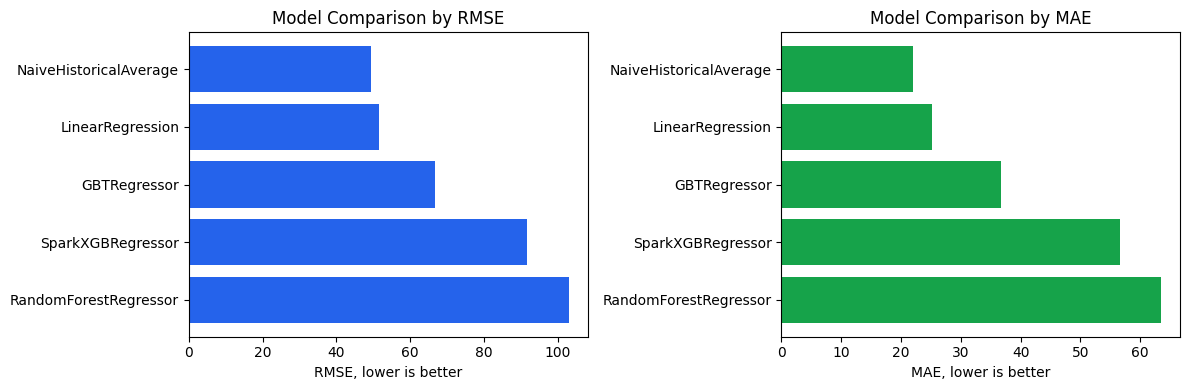

In [7]:
import matplotlib.pyplot as plt

metrics_pdf = metrics_df.orderBy("rmse").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(metrics_pdf["model"], metrics_pdf["rmse"], color="#2563eb")
axes[0].invert_yaxis()
axes[0].set_title("Model Comparison by RMSE")
axes[0].set_xlabel("RMSE, lower is better")

axes[1].barh(metrics_pdf["model"], metrics_pdf["mae"], color="#16a34a")
axes[1].invert_yaxis()
axes[1].set_title("Model Comparison by MAE")
axes[1].set_xlabel("MAE, lower is better")

plt.tight_layout()
plt.show()


## 7. Save Best Model

The best fixed trainable model from the 2025 holdout comparison is saved for reuse by the remaining notebook diagnostics and the application layer.


In [8]:
Path("output").mkdir(exist_ok=True)
best_model_output_path = "output/best_model_taxi_demand"

best_model.write().overwrite().save(best_model_output_path)
print(f"Best model saved to {best_model_output_path}")

print(f"""
Best Trainable Model: {best_model_name}
Best Config: {best_model_config['config_name']}
Params: {best_model_config['params_text']}
RMSE: {best_result['rmse']:.4f}
MAE: {best_result['mae']:.4f}
R2: {best_result['r2']:.4f}
""")

gc.collect()


Best model saved to output/best_model_taxi_demand

Best Trainable Model: LinearRegression
Best Config: linear_default
Params: maxIter=30, regParam=0.01, elasticNetParam=0.0
RMSE: 51.6100
MAE: 25.1287
R2: 0.8842



356

In [9]:
print("Model comparison is shown in the previous plot.")


Model comparison is shown in the previous plot.


In [10]:
print(f"Best model already saved to {best_model_output_path}")


Best model already saved to output/best_model_taxi_demand


## 8. Actual vs Predicted Comparison

These diagnostics compare the selected trained model's predictions with the actual 2025 demand counts. The residual is `predicted_trip_count - actual_trip_count`, so positive values mean the model overpredicted demand.

Read the plots carefully: the scatter plot is row-level accuracy for each pickup location/date/hour row, while the hourly line chart is averaged across all rows with the same hour. A model can match the average hourly curve but still miss many individual high-demand or low-demand location rows.

In [11]:
Path("output").mkdir(exist_ok=True)

try:
    test_predictions.unpersist()
except NameError:
    pass

test_predictions = (
    best_model
    .transform(test_features_df)
    .select(
        "PULocationID",
        "pickup_date",
        "pickup_year",
        "pickup_month",
        "pickup_day",
        "pickup_day_of_week",
        "pickup_hour",
        "is_weekend",
        "location_avg",
        "location_hour_avg",
        "location_dow_hour_avg",
        "previous_month_location_hour_avg",
        "location_hour_zero_rate",
        F.col("trip_count").alias("actual_trip_count"),
        F.col("prediction").alias("predicted_trip_count"),
    )
    .withColumn("prediction_error", F.col("predicted_trip_count") - F.col("actual_trip_count"))
    .withColumn("absolute_error", F.abs(F.col("prediction_error")))
    .persist(CACHE_STORAGE_LEVEL)
)

test_prediction_count = test_predictions.count()
print(f"2025 prediction rows: {test_prediction_count:,}")

sample_predictions = (
    test_predictions
    .select(
        "PULocationID",
        "pickup_date",
        "pickup_hour",
        F.round("actual_trip_count", 2).alias("actual_trip_count"),
        F.round("predicted_trip_count", 2).alias("predicted_trip_count"),
        F.round("prediction_error", 2).alias("prediction_error"),
        F.round("absolute_error", 2).alias("absolute_error"),
    )
    .orderBy("PULocationID", "pickup_date", "pickup_hour")
)

sample_predictions.show(10, truncate=False)
sample_predictions.limit(1000).toPandas().to_csv("output/sample_predictions.csv", index=False)
print("Sample predictions saved to output/sample_predictions.csv")

2025 prediction rows: 170,424
+------------+-----------+-----------+-----------------+--------------------+----------------+--------------+
|PULocationID|pickup_date|pickup_hour|actual_trip_count|predicted_trip_count|prediction_error|absolute_error|
+------------+-----------+-----------+-----------------+--------------------+----------------+--------------+
|1           |2025-01-01 |0          |0.0              |-14.14              |-14.14          |14.14         |
|1           |2025-01-01 |1          |0.0              |-13.64              |-13.64          |13.64         |
|1           |2025-01-01 |2          |0.0              |-13.13              |-13.13          |13.13         |
|1           |2025-01-01 |3          |0.0              |-12.62              |-12.62          |12.62         |
|1           |2025-01-01 |4          |0.0              |-12.11              |-12.11          |12.11         |
|1           |2025-01-01 |5          |0.0              |-11.61              |-11.61       

In [12]:
prediction_summary = (
    test_predictions
    .agg(
        F.count("*").alias("rows"),
        F.round(F.avg("actual_trip_count"), 2).alias("avg_actual_trip_count"),
        F.round(F.avg("predicted_trip_count"), 2).alias("avg_predicted_trip_count"),
        F.round(F.avg("prediction_error"), 2).alias("mean_error"),
        F.round(F.avg("absolute_error"), 2).alias("mean_absolute_error"),
        F.round(F.sqrt(F.avg(F.col("prediction_error") * F.col("prediction_error"))), 2).alias("rmse"),
        F.round(F.corr("actual_trip_count", "predicted_trip_count"), 4).alias("actual_prediction_corr"),
    )
)

prediction_summary.show(truncate=False)

zero_actual_summary = (
    test_predictions
    .filter(F.col("actual_trip_count") == 0)
    .agg(
        F.count("*").alias("zero_actual_rows"),
        F.round(F.avg("predicted_trip_count"), 2).alias("avg_prediction_when_actual_zero"),
        F.round(F.max("predicted_trip_count"), 2).alias("max_prediction_when_actual_zero"),
        F.round(F.avg(F.when(F.col("predicted_trip_count") >= 20, 1.0).otherwise(0.0)) * 100.0, 2).alias("pct_zero_rows_predicted_20_plus"),
    )
)

print("Zero-actual rows should now be common because the notebook creates the full location/date/hour grid.")
zero_actual_summary.show(truncate=False)

actual_bucketed_errors = (
    test_predictions
    .withColumn(
        "actual_bucket_order",
        F.when(F.col("actual_trip_count") < 10, 1)
         .when(F.col("actual_trip_count") < 50, 2)
         .when(F.col("actual_trip_count") < 100, 3)
         .when(F.col("actual_trip_count") < 250, 4)
         .otherwise(5),
    )
    .withColumn(
        "actual_trip_count_bucket",
        F.when(F.col("actual_trip_count") < 10, "0-9")
         .when(F.col("actual_trip_count") < 50, "10-49")
         .when(F.col("actual_trip_count") < 100, "50-99")
         .when(F.col("actual_trip_count") < 250, "100-249")
         .otherwise("250+"),
    )
    .groupBy("actual_bucket_order", "actual_trip_count_bucket")
    .agg(
        F.count("*").alias("rows"),
        F.round(F.avg("actual_trip_count"), 2).alias("avg_actual"),
        F.round(F.avg("predicted_trip_count"), 2).alias("avg_predicted"),
        F.round(F.avg("prediction_error"), 2).alias("mean_error"),
        F.round(F.avg("absolute_error"), 2).alias("mae"),
        F.round(F.sqrt(F.avg(F.col("prediction_error") * F.col("prediction_error"))), 2).alias("rmse"),
    )
    .orderBy("actual_bucket_order")
    .drop("actual_bucket_order")
)

print("Error by actual demand bucket. This shows whether high-demand rows are being underpredicted.")
actual_bucketed_errors.show(truncate=False)

worst_location_errors = (
    test_predictions
    .groupBy("PULocationID")
    .agg(
        F.count("*").alias("rows"),
        F.round(F.avg("actual_trip_count"), 2).alias("avg_actual"),
        F.round(F.avg("predicted_trip_count"), 2).alias("avg_predicted"),
        F.round(F.avg("absolute_error"), 2).alias("mae"),
    )
    .filter(F.col("rows") >= 20)
    .orderBy(F.desc("mae"))
)

print("Pickup locations with the largest average errors.")
worst_location_errors.show(10, truncate=False)

largest_errors = (
    test_predictions
    .select(
        "PULocationID",
        "pickup_date",
        "pickup_hour",
        F.round("actual_trip_count", 2).alias("actual_trip_count"),
        F.round("predicted_trip_count", 2).alias("predicted_trip_count"),
        F.round("prediction_error", 2).alias("prediction_error"),
        F.round("absolute_error", 2).alias("absolute_error"),
    )
    .orderBy(F.desc("absolute_error"))
)

print("Largest individual row errors.")
largest_errors.show(10, truncate=False)

+------+---------------------+------------------------+----------+-------------------+-----+----------------------+
|rows  |avg_actual_trip_count|avg_predicted_trip_count|mean_error|mean_absolute_error|rmse |actual_prediction_corr|
+------+---------------------+------------------------+----------+-------------------+-----+----------------------+
|170424|118.99               |114.42                  |-4.57     |25.13              |51.61|0.941                 |
+------+---------------------+------------------------+----------+-------------------+-----+----------------------+

Zero-actual rows should now be common because the notebook creates the full location/date/hour grid.
+----------------+-------------------------------+-------------------------------+-------------------------------+
|zero_actual_rows|avg_prediction_when_actual_zero|max_prediction_when_actual_zero|pct_zero_rows_predicted_20_plus|
+----------------+-------------------------------+-------------------------------+------

## Pickup Location Accuracy Ranking

This chart ranks pickup locations by final 2025 prediction error. Lower MAE means better location-level accuracy. The full ranking is also saved as CSV for review.


26/05/08 05:12:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 0

+-------------+------------+-------------+---------------------------------------------+----+----------+-------------+----+----+-----+
|accuracy_rank|PULocationID|borough      |zone                                         |rows|avg_actual|avg_predicted|mae |rmse|bias |
+-------------+------------+-------------+---------------------------------------------+----+----------+-------------+----+----+-----+
|1            |264         |Unknown      |N/A                                          |648 |8.53      |11.99        |5.36|6.94|3.45 |
|2            |190         |Brooklyn     |Prospect Park                                |648 |13.46     |11.59        |5.93|8.16|-1.86|
|3            |27          |Queens       |Breezy Point/Fort Tilden/Riis Beach          |648 |1.22      |-4.36        |5.98|6.86|-5.59|
|4            |12          |Manhattan    |Battery Park                                 |648 |3.99      |-1.47        |6.01|7.44|-5.47|
|5            |154         |Brooklyn     |Marine Park/F

26/05/08 05:12:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 05:12:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/08 0

Location accuracy ranking saved to output/location_accuracy_ranked.csv


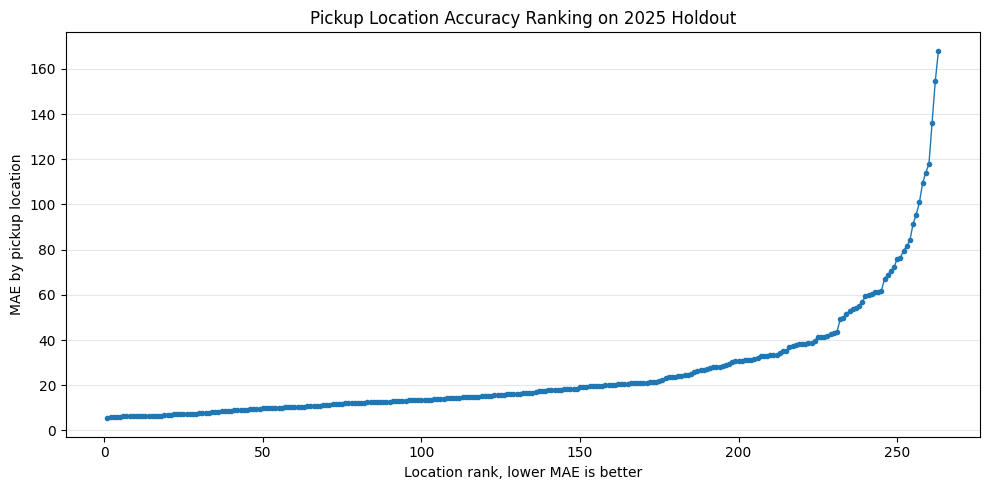

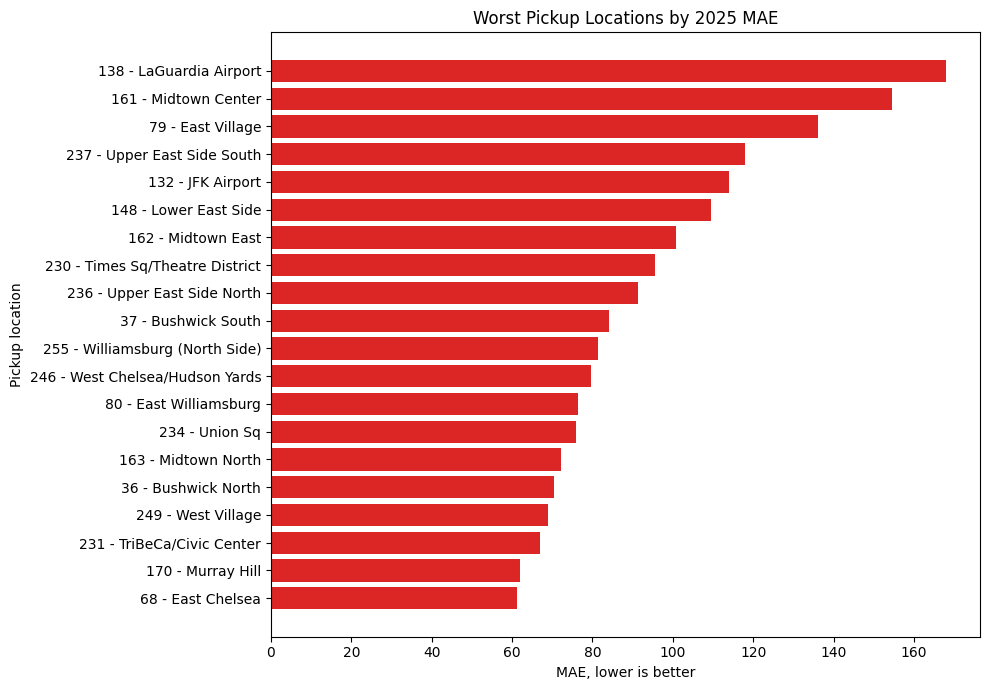

In [13]:
import matplotlib.pyplot as plt

Path("output").mkdir(exist_ok=True)

location_accuracy_df = (
    test_predictions
    .groupBy("PULocationID")
    .agg(
        F.count("*").alias("rows"),
        F.avg("actual_trip_count").alias("avg_actual"),
        F.avg("predicted_trip_count").alias("avg_predicted"),
        F.avg("absolute_error").alias("mae"),
        F.sqrt(F.avg(F.col("prediction_error") * F.col("prediction_error"))).alias("rmse"),
        F.avg("prediction_error").alias("bias"),
    )
    .join(zone_lookup_df.select("PULocationID", "borough", "zone"), "PULocationID", "left")
    .withColumn(
        "accuracy_rank",
        F.row_number().over(Window.orderBy(F.asc("mae"), F.asc("rmse"), F.asc("PULocationID"))),
    )
    .select(
        "accuracy_rank",
        "PULocationID",
        "borough",
        "zone",
        "rows",
        F.round("avg_actual", 2).alias("avg_actual"),
        F.round("avg_predicted", 2).alias("avg_predicted"),
        F.round("mae", 2).alias("mae"),
        F.round("rmse", 2).alias("rmse"),
        F.round("bias", 2).alias("bias"),
    )
    .orderBy("accuracy_rank")
)

location_accuracy_df.show(20, truncate=False)

location_accuracy_pdf = location_accuracy_df.toPandas()
location_accuracy_pdf.to_csv("output/location_accuracy_ranked.csv", index=False)
print("Location accuracy ranking saved to output/location_accuracy_ranked.csv")

if location_accuracy_pdf.empty:
    print("No rows available for location accuracy ranking plot.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        location_accuracy_pdf["accuracy_rank"],
        location_accuracy_pdf["mae"],
        marker=".",
        linewidth=1,
    )
    ax.set_title("Pickup Location Accuracy Ranking on 2025 Holdout")
    ax.set_xlabel("Location rank, lower MAE is better")
    ax.set_ylabel("MAE by pickup location")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    worst_location_pdf = location_accuracy_pdf.sort_values("mae", ascending=False).head(20).copy()
    worst_location_pdf["location_label"] = (
        worst_location_pdf["PULocationID"].astype(str)
        + " - "
        + worst_location_pdf["zone"].fillna("Unknown")
    )
    worst_location_pdf = worst_location_pdf.sort_values("mae")

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(worst_location_pdf["location_label"], worst_location_pdf["mae"], color="#dc2626")
    ax.set_title("Worst Pickup Locations by 2025 MAE")
    ax.set_xlabel("MAE, lower is better")
    ax.set_ylabel("Pickup location")
    plt.tight_layout()
    plt.show()


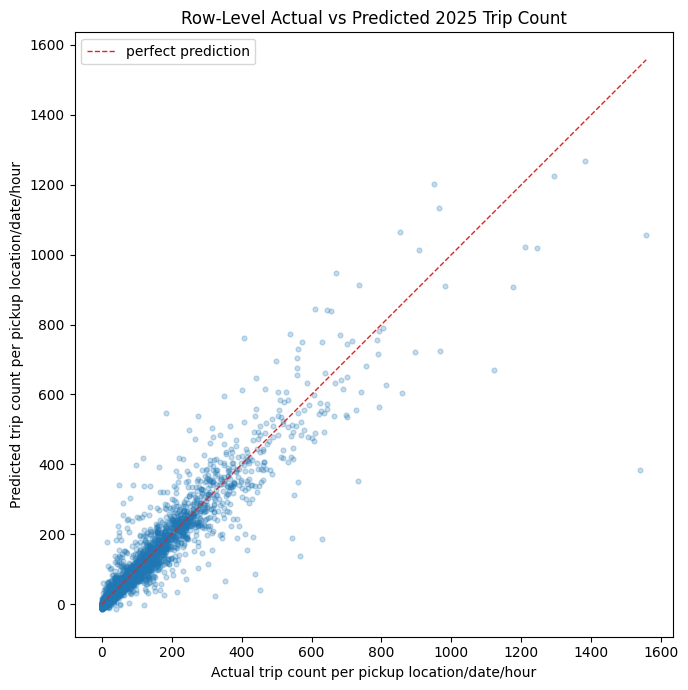

In [14]:
comparison_sample_pdf = (
    test_predictions
    .sample(False, PLOT_SAMPLE_FRACTION, seed=42)
    .limit(PLOT_SAMPLE_LIMIT)
    .select("actual_trip_count", "predicted_trip_count")
    .toPandas()
)

if comparison_sample_pdf.empty:
    comparison_sample_pdf = (
        test_predictions
        .limit(PLOT_SAMPLE_LIMIT)
        .select("actual_trip_count", "predicted_trip_count")
        .toPandas()
    )

if comparison_sample_pdf.empty:
    print("No rows available for actual vs predicted plot.")
else:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(
        comparison_sample_pdf["actual_trip_count"],
        comparison_sample_pdf["predicted_trip_count"],
        alpha=0.25,
        s=12,
    )

    max_axis = max(
        comparison_sample_pdf["actual_trip_count"].max(),
        comparison_sample_pdf["predicted_trip_count"].max(),
        1,
    )
    ax.plot([0, max_axis], [0, max_axis], color="#dc2626", linestyle="--", linewidth=1, label="perfect prediction")
    ax.set_title("Row-Level Actual vs Predicted 2025 Trip Count")
    ax.set_xlabel("Actual trip count per pickup location/date/hour")
    ax.set_ylabel("Predicted trip count per pickup location/date/hour")
    ax.legend()
    plt.tight_layout()
    plt.show()

This hourly plot is averaged across all pickup locations and dates. Use it for time-of-day trend only; use the scatter and error buckets for row-level accuracy.


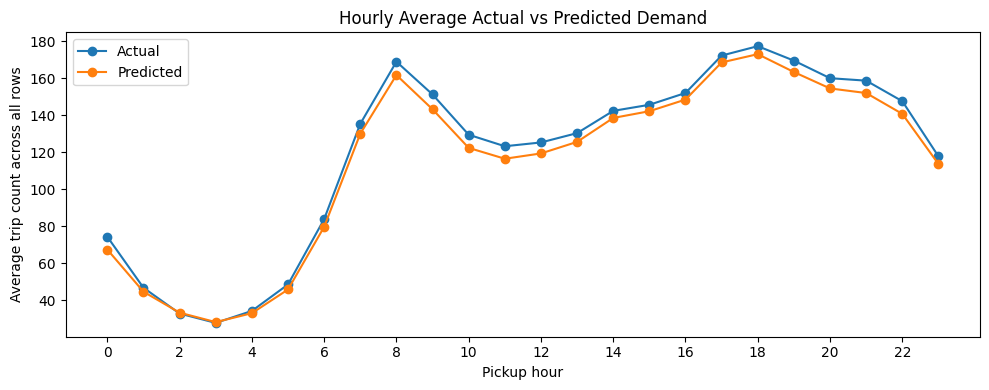

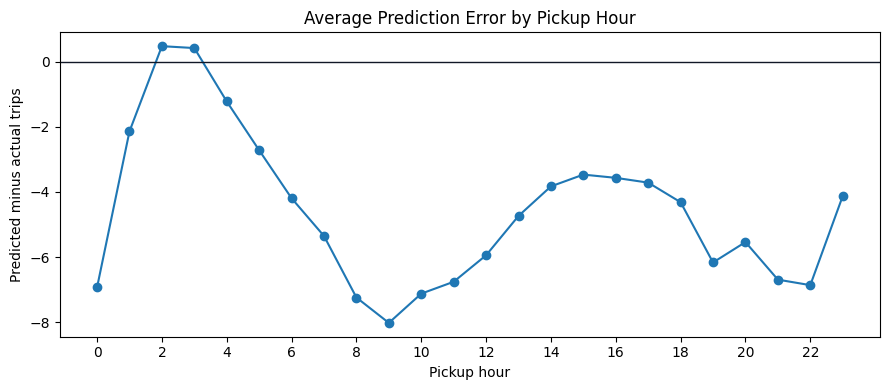

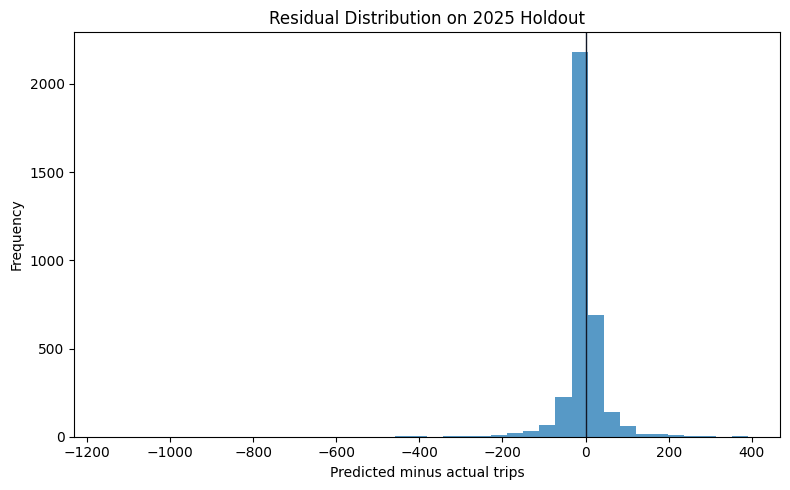

In [15]:
hourly_comparison_pdf = (
    test_predictions
    .groupBy("pickup_hour")
    .agg(
        F.avg("actual_trip_count").alias("avg_actual_trip_count"),
        F.avg("predicted_trip_count").alias("avg_predicted_trip_count"),
        F.avg("prediction_error").alias("avg_prediction_error"),
    )
    .orderBy("pickup_hour")
    .toPandas()
)

if hourly_comparison_pdf.empty:
    print("No rows available for hourly actual vs predicted plot.")
else:
    print("This hourly plot is averaged across all pickup locations and dates. Use it for time-of-day trend only; use the scatter and error buckets for row-level accuracy.")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(hourly_comparison_pdf["pickup_hour"], hourly_comparison_pdf["avg_actual_trip_count"], marker="o", label="Actual")
    ax.plot(hourly_comparison_pdf["pickup_hour"], hourly_comparison_pdf["avg_predicted_trip_count"], marker="o", label="Predicted")
    ax.set_title("Hourly Average Actual vs Predicted Demand")
    ax.set_xlabel("Pickup hour")
    ax.set_ylabel("Average trip count across all rows")
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(hourly_comparison_pdf["pickup_hour"], hourly_comparison_pdf["avg_prediction_error"], marker="o")
    ax.axhline(0, color="#111827", linewidth=1)
    ax.set_title("Average Prediction Error by Pickup Hour")
    ax.set_xlabel("Pickup hour")
    ax.set_ylabel("Predicted minus actual trips")
    ax.set_xticks(range(0, 24, 2))
    plt.tight_layout()
    plt.show()

residual_pdf = (
    test_predictions
    .sample(False, PLOT_SAMPLE_FRACTION, seed=24)
    .limit(PLOT_SAMPLE_LIMIT)
    .select("prediction_error")
    .toPandas()
)

if not residual_pdf.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(residual_pdf["prediction_error"], bins=40, alpha=0.75)
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_title("Residual Distribution on 2025 Holdout")
    ax.set_xlabel("Predicted minus actual trips")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 9. Save Streamlit Prediction Output

Streamlit should not train the model. This section creates a small prediction table for one selected month, with one row for each pickup zone, day of week, and hour. The app can read this precomputed output directly.

In [16]:
serving_month_index = SERVING_PREDICTION_YEAR * 12 + SERVING_PREDICTION_MONTH

pickup_locations_df = demand_df.select("PULocationID", "PULocationID_string").distinct()
day_of_week_df = spark.range(1, 8).select(F.col("id").cast("int").alias("pickup_day_of_week"))
hour_df = spark.range(0, 24).select(F.col("id").cast("int").alias("pickup_hour"))

serving_grid_df = (
    pickup_locations_df
    .crossJoin(day_of_week_df)
    .crossJoin(hour_df)
    .withColumn("pickup_year", F.lit(SERVING_PREDICTION_YEAR).cast("int"))
    .withColumn("pickup_month", F.lit(SERVING_PREDICTION_MONTH).cast("int"))
    .withColumn("pickup_day", F.lit(1).cast("int"))
    .withColumn("pickup_date", date_from_year_month_day(F.col("pickup_year"), F.col("pickup_month"), F.col("pickup_day")))
    .withColumn("month_index", F.lit(serving_month_index).cast("int"))
    .withColumn("is_weekend", F.col("pickup_day_of_week").isin([1, 7]))
    .withColumn("is_weekend_int", F.col("is_weekend").cast("int"))
)

serving_dataset = add_historical_features(serving_grid_df, history_tables)
serving_features_df = feature_model.transform(serving_dataset).select(serving_feature_columns_to_keep)

serving_predictions = (
    best_model
    .transform(serving_features_df)
    .withColumn("predicted_trip_count", F.greatest(F.col("prediction"), F.lit(0.0)))
    .join(zone_lookup_df, "PULocationID", "left")
    .withColumn("prediction_timestamp", F.current_timestamp())
    .withColumn(
        "demand_level",
        F.when(F.col("predicted_trip_count") < 20, "low")
         .when(F.col("predicted_trip_count") < 50, "medium")
         .when(F.col("predicted_trip_count") < 100, "high")
         .otherwise("very_high"),
    )
    .select(
        "prediction_timestamp",
        "PULocationID",
        "borough",
        "zone",
        "pickup_year",
        "pickup_month",
        "pickup_day_of_week",
        "pickup_hour",
        F.round("predicted_trip_count", 2).alias("predicted_trip_count"),
        "demand_level",
    )
)

print(f"Serving prediction month: {SERVING_PREDICTION_YEAR}-{SERVING_PREDICTION_MONTH:02d}")
print(f"Serving prediction rows: {serving_predictions.count():,}")
serving_predictions.orderBy("pickup_hour", F.desc("predicted_trip_count")).show(10, truncate=False)

Serving prediction month: 2025-01
Serving prediction rows: 44,184


+--------------------------+------------+---------+------------+-----------+------------+------------------+-----------+--------------------+------------+
|prediction_timestamp      |PULocationID|borough  |zone        |pickup_year|pickup_month|pickup_day_of_week|pickup_hour|predicted_trip_count|demand_level|
+--------------------------+------------+---------+------------+-----------+------------+------------------+-----------+--------------------+------------+
|2026-05-08 05:12:18.731871|132         |Queens   |JFK Airport |2025       |1           |1                 |0          |956.55              |very_high   |
|2026-05-08 05:12:18.731871|79          |Manhattan|East Village|2025       |1           |1                 |0          |953.34              |very_high   |
|2026-05-08 05:12:18.731871|132         |Queens   |JFK Airport |2025       |1           |2                 |0          |952.45              |very_high   |
|2026-05-08 05:12:18.731871|132         |Queens   |JFK Airport |2025  

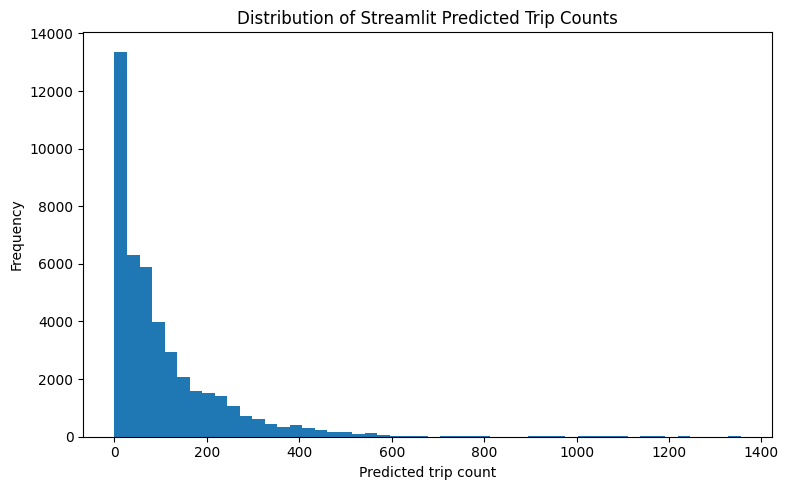

In [17]:
# Predicted trip count distribution for the Streamlit output.
prediction_distribution_pdf = serving_predictions.select("predicted_trip_count").toPandas()

plt.figure(figsize=(8, 5))
plt.hist(prediction_distribution_pdf["predicted_trip_count"], bins=50)
plt.title("Distribution of Streamlit Predicted Trip Counts")
plt.xlabel("Predicted trip count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
# Highest predicted pickup zones for the selected month.
top_serving_predictions = (
    serving_predictions
    .orderBy(F.desc("predicted_trip_count"))
    .select(
        "PULocationID",
        "borough",
        "zone",
        "pickup_month",
        "pickup_day_of_week",
        "pickup_hour",
        "predicted_trip_count",
        "demand_level",
    )
)

top_serving_predictions.show(20, truncate=False)

+------------+-------+-----------------+------------+------------------+-----------+--------------------+------------+
|PULocationID|borough|zone             |pickup_month|pickup_day_of_week|pickup_hour|predicted_trip_count|demand_level|
+------------+-------+-----------------+------------+------------------+-----------+--------------------+------------+
|132         |Queens |JFK Airport      |1           |1                 |22         |1354.93             |very_high   |
|132         |Queens |JFK Airport      |1           |1                 |23         |1353.23             |very_high   |
|132         |Queens |JFK Airport      |1           |2                 |22         |1350.83             |very_high   |
|132         |Queens |JFK Airport      |1           |2                 |23         |1349.13             |very_high   |
|132         |Queens |JFK Airport      |1           |3                 |22         |1348.77             |very_high   |
|132         |Queens |JFK Airport      |1       

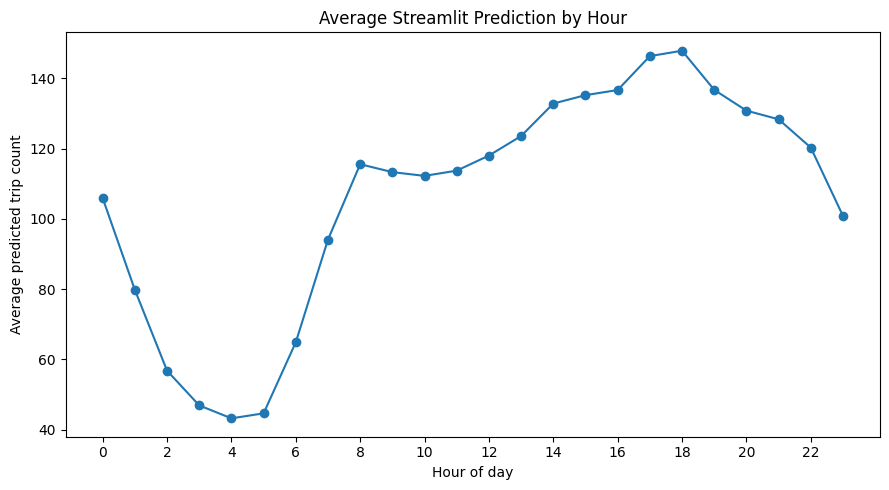

In [19]:
# Average predicted demand by pickup hour for Streamlit.
hourly_serving_pdf = (
    serving_predictions
    .groupBy("pickup_hour")
    .agg(F.avg("predicted_trip_count").alias("avg_predicted_trip_count"))
    .orderBy("pickup_hour")
    .toPandas()
)

plt.figure(figsize=(9, 5))
plt.plot(hourly_serving_pdf["pickup_hour"], hourly_serving_pdf["avg_predicted_trip_count"], marker="o")
plt.title("Average Streamlit Prediction by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Average predicted trip count")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

In [20]:
Path("output").mkdir(exist_ok=True)
streamlit_predictions_path = "output/streamlit_predictions"
streamlit_predictions_csv_path = "output/streamlit_predictions_csv"

serving_predictions.write.mode("overwrite").parquet(streamlit_predictions_path)
(
    serving_predictions
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(streamlit_predictions_csv_path)
)

print(f"Streamlit predictions saved to {streamlit_predictions_path}")
print(f"Streamlit CSV export saved to {streamlit_predictions_csv_path}")

Streamlit predictions saved to output/streamlit_predictions
Streamlit CSV export saved to output/streamlit_predictions_csv


In [21]:
print("Best model and Streamlit prediction outputs are saved. Continue to Stop Spark when finished.")

Best model and Streamlit prediction outputs are saved. Continue to Stop Spark when finished.


## 10. Stop Spark

Stop the Spark session when the demo is finished so local resources are released.


In [22]:
for cached_name in [
    "positive_demand_df",
    "demand_df",
    "dataset",
    "train_features_df",
    "test_features_df",
    "test_predictions",
]:
    cached_df = globals().get(cached_name)
    if cached_df is not None:
        cached_df.unpersist()

spark.stop()